In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('ticks',
              rc={'axes.facecolor': (0, 0, 0, 0)})
sns.set_context('paper')

from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['figure.dpi'] = 150

In [2]:
import numpy as np
import pandas as pd

In [3]:
c1 = pd.read_csv('../data/pOXA48/plate_counts.tsv', sep='\t')
c2 = pd.read_csv('../data/PN23/plate_counts.tsv', sep='\t')

In [4]:
c1.groupby(['vial', 'short', 'replicate'])['time'].max()

vial  short            replicate
M0    KAN no drug      rep1         136.0
                       rep2         306.0
M1    KAN 16x MIC      rep1         208.0
                       rep2         306.0
M2    KAN+PVI no drug  rep1         208.0
                       rep2         306.0
M3    KAN+PVI 16x MIC  rep1         208.0
                       rep2         306.0
M4    PVI no drug      rep1         208.0
                       rep2         306.0
M5    PVI 16x MIC      rep1         208.0
                       rep2         306.0
M6    PVB no drug      rep1         208.0
                       rep2         306.0
M7    PVB 16x MIC      rep1         208.0
                       rep2         306.0
Name: time, dtype: float64

In [5]:
c1 = c1[~((c1['vial'] == 'M0') & (c1['replicate'] == 'rep1'))].reset_index(drop=True)

In [6]:
for df in [c1, c2]:
    df['replicate'] = df['replicate'].astype(str).str.replace('rep', '')

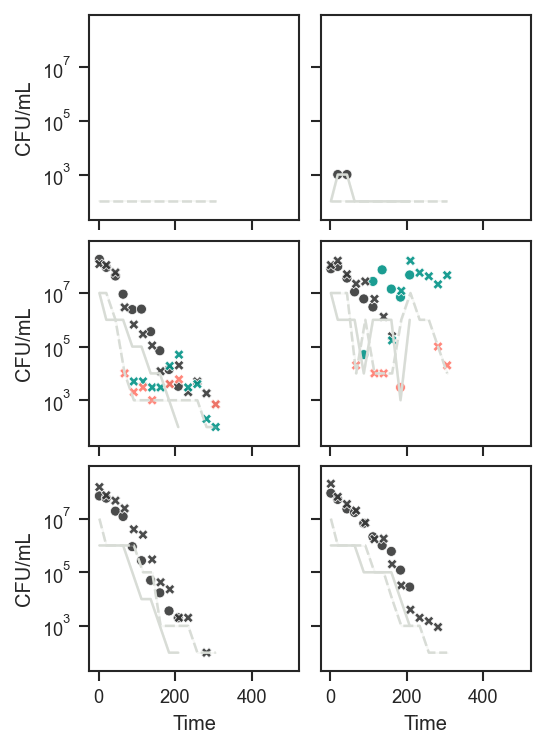

In [7]:
cp = sns.relplot(data=c1[c1['plate'] == 'AMP'],
                 x='time',
                 y='CFU/mL',
                 hue='strain',
                 col='short',
                 col_order=['KAN no drug', 'KAN 16x MIC',
                            'PVI no drug', 'PVI 16x MIC',
                            'PVB no drug', 'PVB 16x MIC'
                           ],
                 col_wrap=2,
                 style='replicate',
                 style_order=['1', '2'],
                 # row_order=['AMP'],
                 # row='plate',
                 height=1.8, aspect=1,
                 alpha=0.9,
                 palette=['xkcd:teal',
                          'xkcd:salmon',
                          'xkcd:dark grey'],
                 hue_order=['PL', 'PM', 'LM'],
                 legend=False)

cp.map_dataframe(sns.lineplot,
                 x='time',
                 y='detection_limit',
                 style='replicate',
                 style_order=['1', '2'],
                 color='xkcd:light grey'
                )

cp.set(
       yscale='log',
       xlabel='Time',
       ylabel='CFU/mL',
       ylim=(20, 9E8),
       xlim=(-25, 525),
       xticks=[0,
               200,
               400,]
)
cp.set_titles("")

sns.despine(right=False, top=False)

plt.subplots_adjust(wspace=0.1, hspace=0.1)

plt.savefig('poxa_selective_plating.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('poxa_selective_plating.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

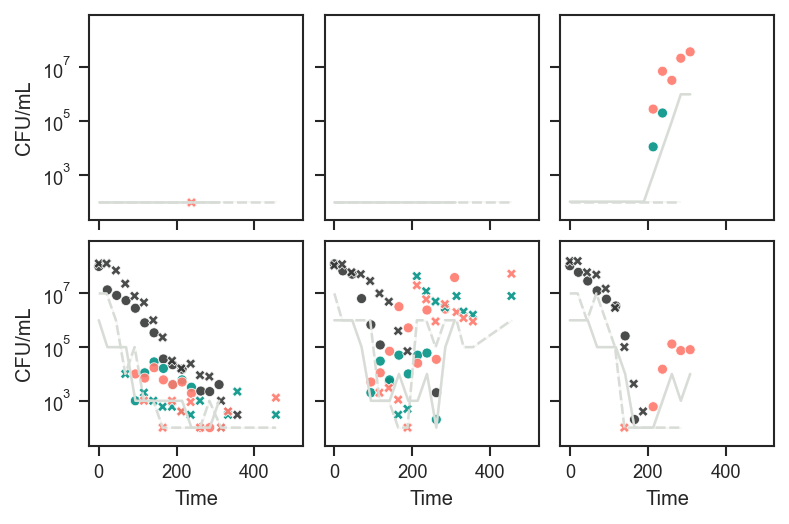

In [8]:
cp = sns.relplot(data=c2[c2['plate'] == 'COL'],
                 x='time',
                 y='CFU/mL',
                 hue='strain',
                 col='short',
                 col_order=['KAN no drug',
                            'KAN 1xMIC',
                            'KAN 2xMIC',
                            'PN23 no drug',
                            'PN23 1xMIC',
                            'PN23 2xMIC'],
                 col_wrap=3,
                 style='replicate',
                 style_order=['1', '2'],
                 # row_order=['AMP'],
                 # row='plate',
                 height=1.95, aspect=0.91,
                 alpha=0.9,
                 palette=['xkcd:teal',
                          'xkcd:salmon',
                          'xkcd:dark grey'],
                 hue_order=['PL', 'PM', 'LM'],
                 legend=False)

cp.map_dataframe(sns.lineplot,
                 x='time',
                 y='detection_limit',
                 style='replicate',
                 style_order=['1', '2'],
                 color='xkcd:light grey'
                )

cp.set(
       yscale='log',
       xlabel='Time',
       ylabel='CFU/mL',
       ylim=(20, 9E8),
       xlim=(-25, 525),
       xticks=[0,
               200,
               400,]
)
cp.set_titles("")

sns.despine(right=False, top=False)

plt.subplots_adjust(wspace=0.1, hspace=0.1)

plt.savefig('pn_selective_plating.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('pn_selective_plating.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);


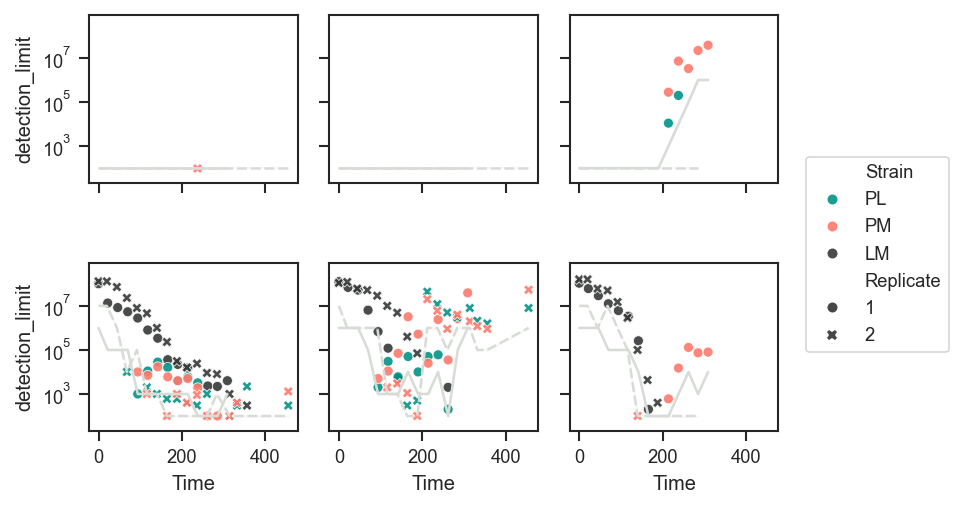

In [9]:
cp = sns.relplot(data=c2[c2['plate'] == 'COL'].rename(columns={'strain': 'Strain',
                                                               'replicate': 'Replicate',
                                                              }),
                 x='time',
                 y='CFU/mL',
                 hue='Strain',
                 col='short',
                 col_order=['KAN no drug',
                            'KAN 1xMIC',
                            'KAN 2xMIC',
                            'PN23 no drug',
                            'PN23 1xMIC',
                            'PN23 2xMIC'],
                 col_wrap=3,
                 style='Replicate',
                 style_order=['1', '2'],
                 # row_order=['AMP'],
                 # row='plate',
                 height=1.9, aspect=0.95,
                 alpha=0.9,
                 palette=['xkcd:teal',
                          'xkcd:salmon',
                          'xkcd:dark grey'],
                 hue_order=['PL', 'PM', 'LM'],
                 legend=True,
                )

cp.map_dataframe(sns.lineplot,
                 x='time',
                 y='detection_limit',
                 style='Replicate',
                 style_order=['1', '2'],
                 color='xkcd:light grey'
                )

cp.set(
       yscale='log',
       xlabel='Time',
       ylim=(20, 9E8)
)
cp.set_titles("")

cp._legend.set_frame_on(True)
cp._legend.get_frame().set_facecolor('white')

sns.despine(right=False, top=False)

plt.savefig('pn_selective_plating_legend.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('pn_selective_plating_legend.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);


In [10]:
m1 = pd.read_csv('../data/pOXA48/chibio.tsv.gz', sep='\t')
m2 = pd.read_csv('../data/PN23/chibio.tsv.gz', sep='\t')

In [11]:
m1 = m1[~((m1['vial'] == 'M0') & (m1['replicate'] == 'rep1'))].reset_index(drop=True)

In [12]:
for df in [m1, m2]:
    df['replicate'] = df['replicate'].astype(str).str.replace('rep', '')

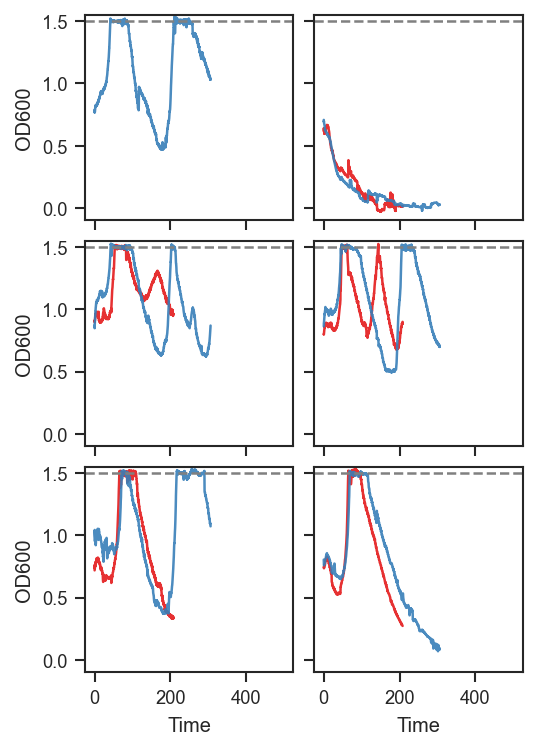

In [13]:
cp = sns.relplot(data=m1,
                 x='time',
                 y='smooth_od',
                 col='short',
                 col_wrap=2,
                 col_order=['KAN no drug', 'KAN 16x MIC',
                            'PVI no drug', 'PVI 16x MIC',
                            'PVB no drug', 'PVB 16x MIC'
                           ],
                 hue='replicate',
                 hue_order=['1', '2'],
                 palette='Set1',
                 kind='line',
                 height=1.7, aspect=1.08,
                 alpha=0.9,
                 legend=False
                )

cp.set(
    xlabel='Time',
    ylabel='OD600',
    ylim=(-0.1, 1.55),
    xlim=(-25, 525),
    xticks=[0,
            200,
            400,]
)
cp.set_titles("")
cp.map(plt.axhline, y=1.5, color='grey', linestyle='--')

plt.subplots_adjust(wspace=0.1, hspace=0.1)

sns.despine(right=False, top=False)

plt.savefig('poxa_chibio_od.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('poxa_chibio_od.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

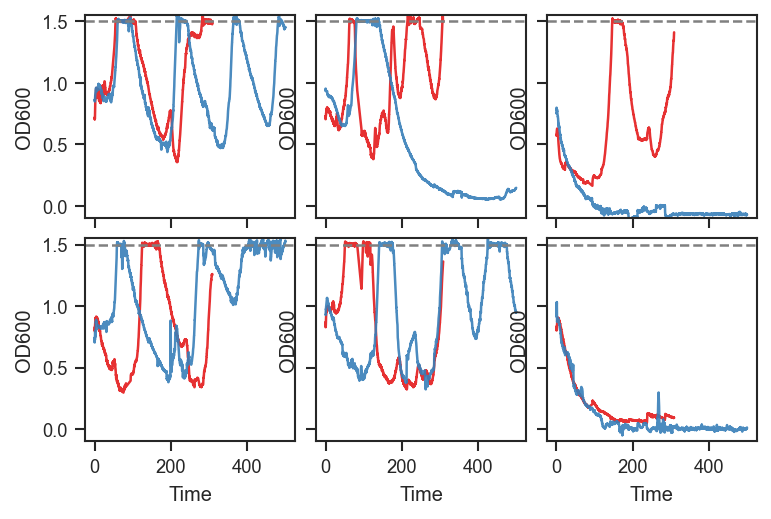

In [14]:
cp = sns.relplot(data=m2,
                 x='time',
                 y='smooth_od',
                 col='short',
                 col_wrap=3,
                 col_order=['KAN no drug',
                            'KAN 1xMIC',
                            'KAN 2xMIC',
                            'PN23 no drug',
                            'PN23 1xMIC',
                            'PN23 2xMIC'],
                 hue='replicate',
                 hue_order=['1', '2'],
                 palette='Set1',
                 kind='line',
                 height=1.78, aspect=0.98,
                 alpha=0.9,
                 legend=False
                )

cp.set(
    xlabel='Time',
    ylabel='OD600',
    ylim=(-0.1, 1.55),
    xlim=(-25, 525),
    xticks=[0,
            200,
            400,]
)
cp.set_titles("")
cp.map(plt.axhline, y=1.5, color='grey', linestyle='--')

plt.subplots_adjust(wspace=0.1, hspace=0.1)

sns.despine(right=False, top=False)

plt.savefig('pn_chibio_od.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('pn_chibio_od.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

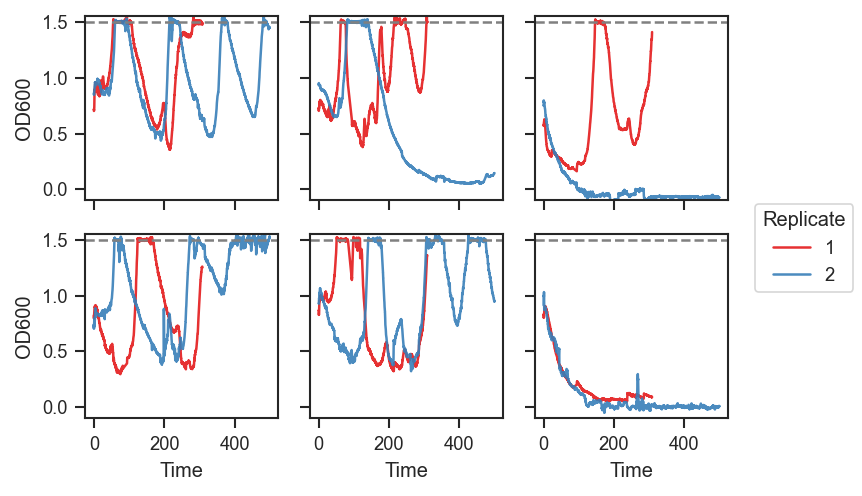

In [15]:
cp = sns.relplot(data=m2.rename(columns={'replicate': 'Replicate'}),
                 x='time',
                 y='smooth_od',
                 col='short',
                 col_wrap=3,
                 col_order=['KAN no drug',
                            'KAN 1xMIC',
                            'KAN 2xMIC',
                            'PN23 no drug',
                            'PN23 1xMIC',
                            'PN23 2xMIC'],
                 hue='Replicate',
                 hue_order=['1', '2'],
                 palette='Set1',
                 kind='line',
                 height=1.7, aspect=1.,
                 alpha=0.9,
                 legend=True
                )

cp.set(
    xlabel='Time',
    ylabel='OD600',
    ylim=(-0.1, 1.55)
)
cp.set_titles("")
cp.map(plt.axhline, y=1.5, color='grey', linestyle='--')

cp._legend.set_frame_on(True)
cp._legend.get_frame().set_facecolor('white')

sns.despine(right=False, top=False)

plt.savefig('pn_chibio_od_legend.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('pn_chibio_od_legend.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

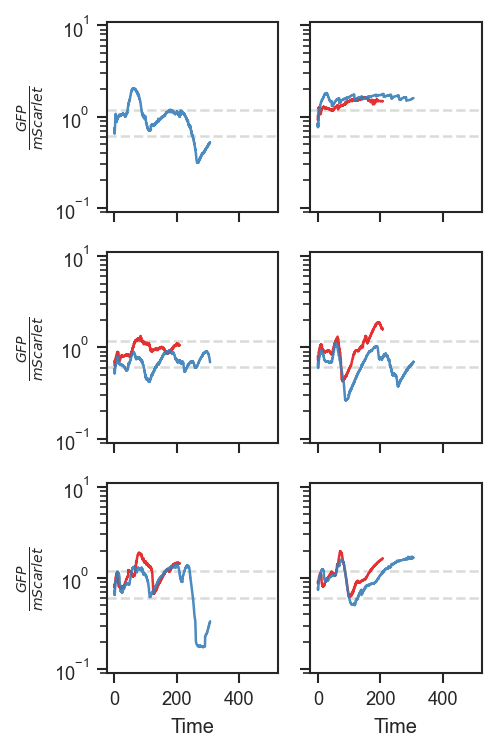

In [16]:
cp = sns.relplot(data=m1,
                 x='time',
                 y='smooth_norm_FP1_emit1_FP2_emit1_ratio',
                 col='short',
                 col_wrap=2,
                 col_order=['KAN no drug', 'KAN 16x MIC',
                            'PVI no drug', 'PVI 16x MIC',
                            'PVB no drug', 'PVB 16x MIC'
                           ],
                 hue='replicate',
                 hue_order=['1', '2'],
                 palette='Set1',
                 kind='line',
                 height=1.7, aspect=1.,
                 alpha=0.9,
                 legend=False
                )

cp.set(
    yscale='log',
    ylim=(0.09, 11),
    ylabel=r'$\frac{GFP}{mScarlet}$',
    xlabel='Time',
    xlim=(-25, 525),
    xticks=[0,
            200,
            400,]
)
cp.set_titles("")

plt.subplots_adjust(wspace=0.1, hspace=0.1)

cp.map(plt.axhline, y=0.61,
       color='xkcd:light grey',
       zorder=-1,
       linestyle='--')
cp.map(plt.axhline, y=1.18,
       color='xkcd:light grey',
       zorder=-1,
       linestyle='--')

sns.despine(right=False, top=False)

plt.savefig('poxa_chibio_ratio.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('poxa_chibio_ratio.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

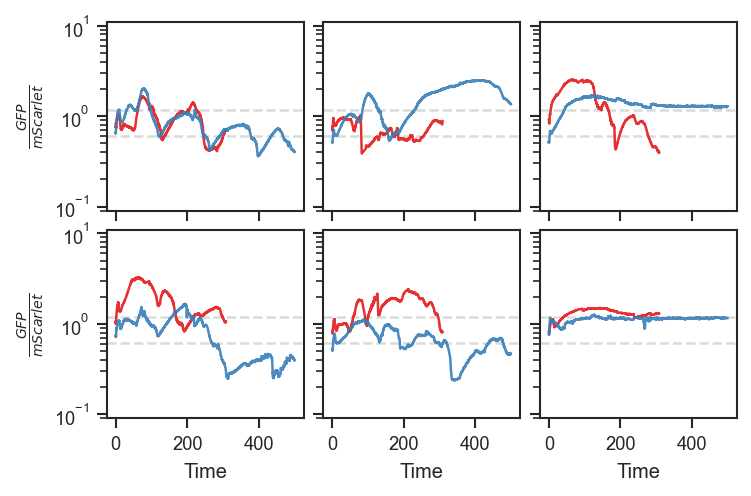

In [17]:
cp = sns.relplot(data=m2,
                 x='time',
                 y='smooth_norm_FP1_emit1_FP2_emit1_ratio',
                 col='short',
                 col_wrap=3,
                 col_order=['KAN no drug', 'KAN 1xMIC', 'KAN 2xMIC',
                            'PN23 no drug', 'PN23 1xMIC', 'PN23 2xMIC'
                           ],
                 hue='replicate',
                 hue_order=['1', '2'],
                 palette='Set1',
                 kind='line',
                 height=1.7, aspect=1.,
                 alpha=0.9,
                 legend=False
                )

cp.set(
    yscale='log',
    ylim=(0.09, 11),
    ylabel=r'$\frac{GFP}{mScarlet}$',
    xlabel='Time',
    xlim=(-25, 525),
    xticks=[0,
            200,
            400,]
)
cp.set_titles("")

cp.map(plt.axhline, y=0.61,
       color='xkcd:light grey',
       zorder=-1,
       linestyle='--')
cp.map(plt.axhline, y=1.18,
       color='xkcd:light grey',
       zorder=-1,
       linestyle='--')

sns.despine(right=False, top=False)

plt.subplots_adjust(wspace=0.1, hspace=0.1)

plt.savefig('pn_chibio_ratio.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('pn_chibio_ratio.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

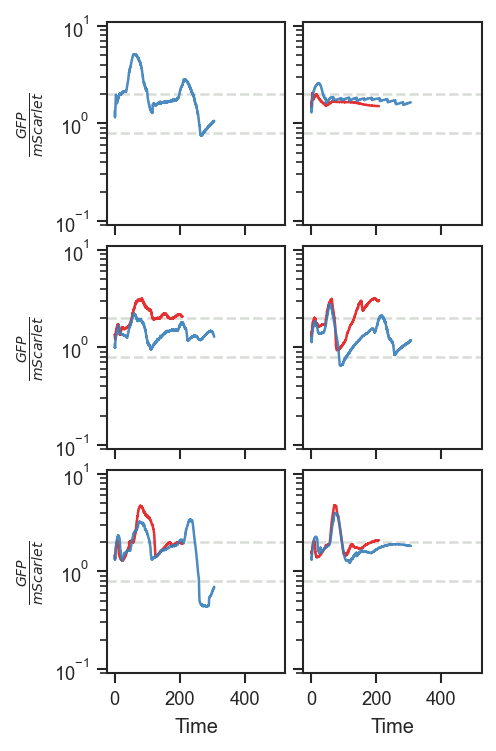

In [18]:
cp = sns.relplot(data=m1,
                 x='time',
                 y='smooth_FP1_emit1_FP2_emit1_ratio',
                 col='short',
                 col_wrap=2,
                 col_order=['KAN no drug', 'KAN 16x MIC',
                            'PVI no drug', 'PVI 16x MIC',
                            'PVB no drug', 'PVB 16x MIC'
                           ],
                 hue='replicate',
                 hue_order=['1', '2'],
                 palette='Set1',
                 kind='line',
                 height=1.7, aspect=1.,
                 alpha=0.9,
                 legend=False
                )

cp.set(
    yscale='log',
    ylim=(0.09, 11),
    ylabel=r'$\frac{GFP}{mScarlet}$',
    xlabel='Time',
    xlim=(-25, 525),
    xticks=[0,
            200,
            400,]
)
cp.set_titles("")

cp.map(plt.axhline, y=0.8,
       color='xkcd:light grey',
       zorder=-1,
       linestyle='--')
cp.map(plt.axhline, y=2,
       color='xkcd:light grey',
       zorder=-1,
       linestyle='--')

sns.despine(right=False, top=False)

plt.subplots_adjust(wspace=0.1, hspace=0.1)

plt.savefig('poxa_chibio_ratio_raw.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('poxa_chibio_ratio_raw.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

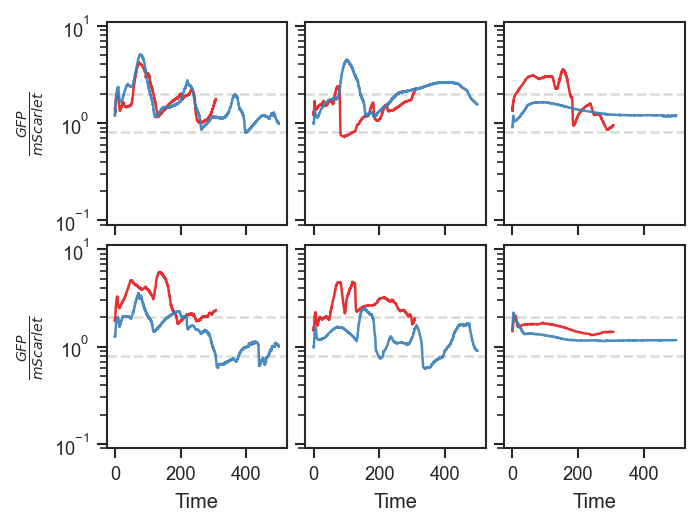

In [19]:
cp = sns.relplot(data=m2,
                 x='time',
                 y='smooth_FP1_emit1_FP2_emit1_ratio',
                 col='short',
                 col_wrap=3,
                 col_order=['KAN no drug', 'KAN 1xMIC', 'KAN 2xMIC',
                            'PN23 no drug', 'PN23 1xMIC', 'PN23 2xMIC'
                           ],
                 hue='replicate',
                 hue_order=['1', '2'],
                 palette='Set1',
                 kind='line',
                 height=1.8, aspect=0.88,
                 alpha=0.9,
                 legend=False
                )

cp.set(
    yscale='log',
    ylim=(0.09, 11),
    ylabel=r'$\frac{GFP}{mScarlet}$',
    xlabel='Time',
    xlim=(-25, 525),
    xticks=[0,
            200,
            400,]
)
cp.set_titles("")

cp.map(plt.axhline, y=0.8,
       color='xkcd:light grey',
       zorder=-1,
       linestyle='--')
cp.map(plt.axhline, y=2,
       color='xkcd:light grey',
       zorder=-1,
       linestyle='--')

sns.despine(right=False, top=False)

plt.subplots_adjust(wspace=0.1, hspace=0.1)

plt.savefig('pn_chibio_ratio_raw.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('pn_chibio_ratio_raw.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

In [20]:
cr1 = c1.groupby(['vial', 'replicate', 'name', 'short', 'plasmid', 'drug', 'time', 'plate']).apply(
               lambda x: (x[x['strain'] == 'PL']['CFU/mL'].mean() /
                          x[x['strain'] == 'PM']['CFU/mL'].mean()) /
                          x['CFU/mL'].sum(),
    include_groups=False).reset_index().rename(columns={0: 'PL / PM'})

In [21]:
cr2 = c2.groupby(['vial', 'replicate', 'name', 'short', 'plasmid', 'drug', 'time', 'plate']).apply(
               lambda x: (x[x['strain'] == 'PL']['CFU/mL'].mean() /
                          x[x['strain'] == 'PM']['CFU/mL'].mean()) /
                          x['CFU/mL'].sum(),
    include_groups=False).reset_index().rename(columns={0: 'PL / PM'})

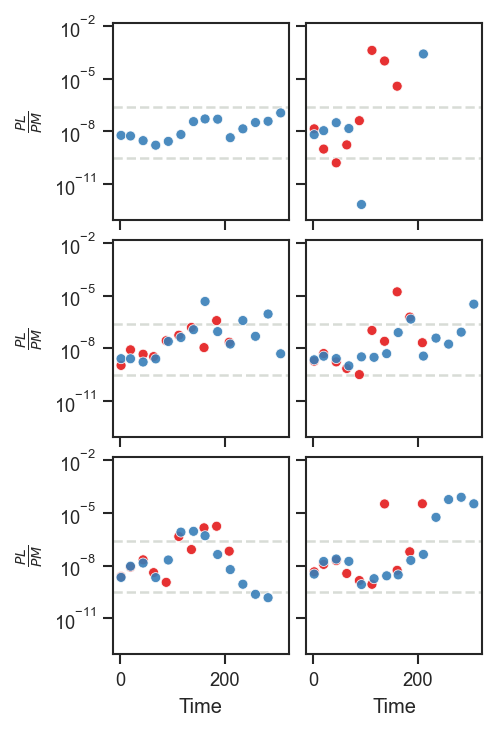

In [22]:
cp = sns.relplot(data=cr1[cr1['plate'] == 'KAN'],
                 x='time',
                 y='PL / PM',
                 col='short',
                 col_wrap=2,
                 col_order=['KAN no drug', 'KAN 16x MIC',
                            'PVI no drug', 'PVI 16x MIC',
                            'PVB no drug', 'PVB 16x MIC'
                           ],
                 hue='replicate',
                 hue_order=['1', '2'],
                 palette='Set1',
                 # kind='line',
                 height=1.7, aspect=1.,
                 alpha=0.9,
                 legend=False
                )

cp.set(
       yscale='log',
       ylabel=r'$\frac{PL}{PM}$',
       xlabel='Time',
       ylim=(9E-14, 1.5E-2)
       # ylim=(3E-11, 1.5E-3),
      )

cp.map(plt.axhline, y=3E-10,
       color='xkcd:light grey',
       zorder=-1,
       linestyle='--')
cp.map(plt.axhline, y=2.5E-7,
       color='xkcd:light grey',
       zorder=-1,
       linestyle='--')
cp.set_titles("")

sns.despine(right=False, top=False)

plt.subplots_adjust(wspace=0.1, hspace=0.1)

plt.savefig('poxa_counting_ratio.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('poxa_counting_ratio.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

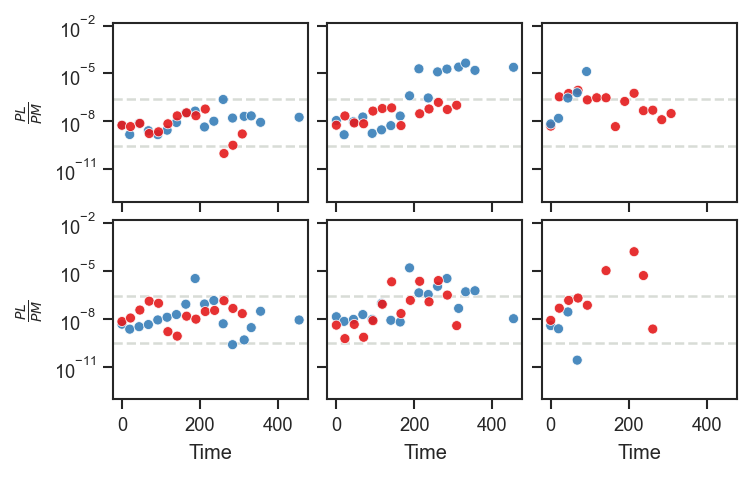

In [23]:
cp = sns.relplot(data=cr2[cr2['plate'] == 'KAN'],
                 x='time',
                 y='PL / PM',
                 col='short',
                 col_wrap=3,
                 col_order=['KAN no drug', 'KAN 1xMIC', 'KAN 2xMIC',
                            'PN23 no drug', 'PN23 1xMIC', 'PN23 2xMIC'
                           ],
                 hue='replicate',
                 hue_order=['1', '2'],
                 palette='Set1',
                 # kind='line',
                 height=1.7, aspect=1.,
                 alpha=0.9,
                 legend=False
                )

cp.set(
       yscale='log',
       ylabel=r'$\frac{PL}{PM}$',
       xlabel='Time',
       ylim=(9E-14, 1.5E-2)
       # ylim=(3E-11, 1.5E-3),
      )

cp.map(plt.axhline, y=3E-10,
       color='xkcd:light grey',
       zorder=-1,
       linestyle='--')
cp.map(plt.axhline, y=2.5E-7,
       color='xkcd:light grey',
       zorder=-1,
       linestyle='--')
cp.set_titles("")

sns.despine(right=False, top=False)

plt.subplots_adjust(wspace=0.1, hspace=0.1)

plt.savefig('pn_counting_ratio.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('pn_counting_ratio.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

In [24]:
f1 = pd.read_csv('../data/pOXA48/flow_cytometer.tsv', sep='\t')
f2 = pd.read_csv('../data/PN23/flow_cytometer.tsv', sep='\t')

In [25]:
f1 = f1[~((f1['vial'] == 'M0') & (f1['replicate'] == 'rep1'))].reset_index(drop=True)

In [26]:
for df in [f1, f2]:
    df['replicate'] = df['replicate'].astype(str).str.replace('rep', '')

In [27]:
fr1 = f1.groupby(['vial', 'replicate', 'name', 'short', 'plasmid', 'drug', 'time']).apply(
               lambda x: (x[x['strain'] == 'PL']['events'].mean() /
                          x[x['strain'] == 'PM']['events'].mean()),
    include_groups=False).reset_index().rename(columns={0: 'PL / PM'})

In [28]:
fr2 = f2.groupby(['vial', 'replicate', 'name', 'short', 'plasmid', 'drug', 'time']).apply(
               lambda x: (x[x['strain'] == 'PL']['events'].mean() /
                          x[x['strain'] == 'PM']['events'].mean()),
    include_groups=False).reset_index().rename(columns={0: 'PL / PM'})

/tmp/ipykernel_1890769/1333859499.py:2: RuntimeWarning: divide by zero encountered in scalar divide
  lambda x: (x[x['strain'] == 'PL']['events'].mean() /
/tmp/ipykernel_1890769/1333859499.py:2: RuntimeWarning: invalid value encountered in scalar divide
  lambda x: (x[x['strain'] == 'PL']['events'].mean() /


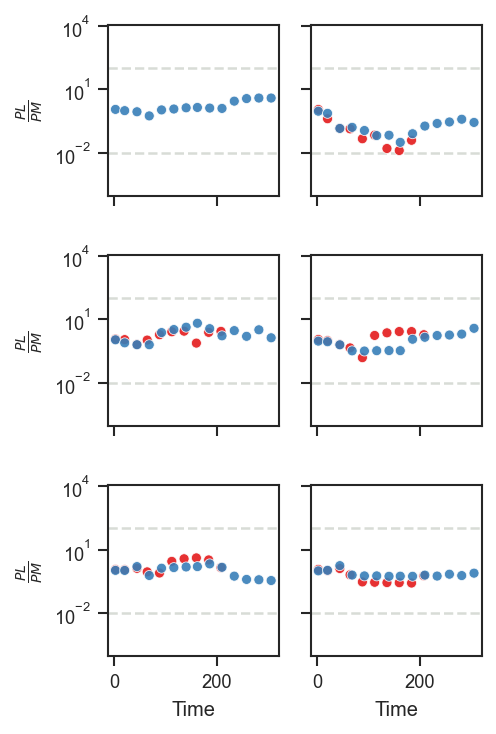

In [29]:
cp = sns.relplot(data=fr1,
                 x='time',
                 y='PL / PM',
                 col='short',
                 col_wrap=2,
                 col_order=['KAN no drug', 'KAN 16x MIC',
                            'PVI no drug', 'PVI 16x MIC',
                            'PVB no drug', 'PVB 16x MIC'
                           ],
                 hue='replicate',
                 hue_order=['1', '2'],
                 palette='Set1',
                 # kind='line',
                 height=1.7, aspect=1.,
                 alpha=0.9,
                 legend=False
                )

cp.set(
       yscale='log',
       ylabel=r'$\frac{PL}{PM}$',
       xlabel='Time',
       ylim=(0.00009, 11000)
      )

cp.map(plt.axhline, y=0.01,
       color='xkcd:light grey',
       zorder=-1,
       linestyle='--')
cp.map(plt.axhline, y=100,
       color='xkcd:light grey',
       zorder=-1,
       linestyle='--')
cp.set_titles("")

sns.despine(right=False, top=False)

plt.savefig('poxa_flow_ratio.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('poxa_flow_ratio.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

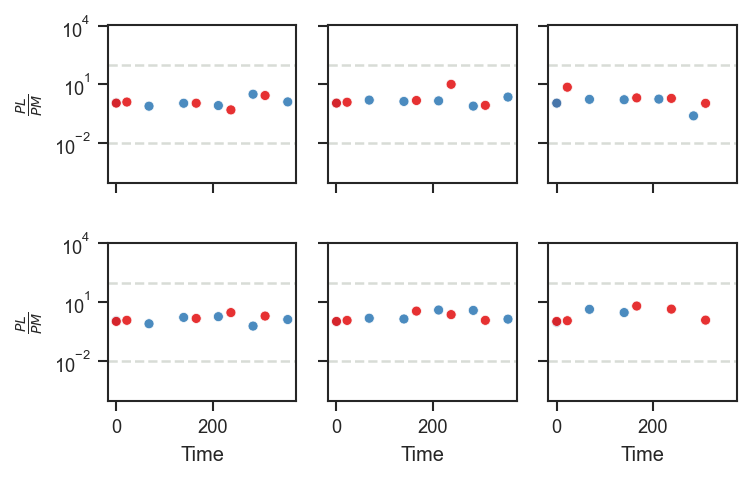

In [30]:
cp = sns.relplot(data=fr2,
                 x='time',
                 y='PL / PM',
                 col='short',
                 col_wrap=3,
                 col_order=['KAN no drug', 'KAN 1xMIC', 'KAN 2xMIC',
                            'PN23 no drug', 'PN23 1xMIC', 'PN23 2xMIC'
                           ],
                 hue='replicate',
                 hue_order=['1', '2'],
                 palette='Set1',
                 # kind='line',
                 height=1.7, aspect=1.,
                 alpha=0.9,
                 legend=False
                )

cp.set(
       yscale='log',
       ylabel=r'$\frac{PL}{PM}$',
       xlabel='Time',
       ylim=(0.00009, 11000)
      )

cp.map(plt.axhline, y=0.01,
       color='xkcd:light grey',
       zorder=-1,
       linestyle='--')
cp.map(plt.axhline, y=100,
       color='xkcd:light grey',
       zorder=-1,
       linestyle='--')
cp.set_titles("")

sns.despine(right=False, top=False)

plt.savefig('pn_flow_ratio.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('pn_flow_ratio.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

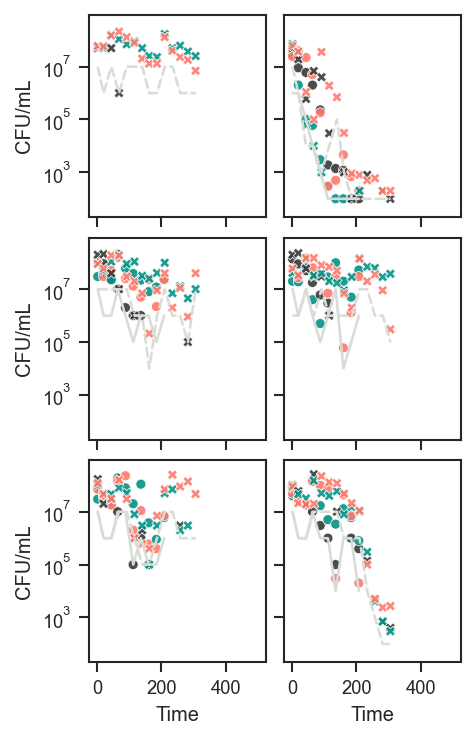

In [34]:
cp = sns.relplot(data=c1[c1['plate'] == 'KAN'],
                 x='time',
                 y='CFU/mL',
                 col='short',
                 col_wrap=2,
                 col_order=['KAN no drug', 'KAN 16x MIC',
                            'PVI no drug', 'PVI 16x MIC',
                            'PVB no drug', 'PVB 16x MIC'
                           ],
                 hue='strain',
                 hue_order=['PL', 'PM', 'LM'],
                 palette=['xkcd:teal',
                          'xkcd:salmon',
                          'xkcd:dark grey'],
                 style='replicate',
                 style_order=['1', '2'],
                 # kind='line',
                 height=1.78, aspect=.88,
                 alpha=0.9,
                 legend=False
                )

cp.map_dataframe(sns.lineplot,
                 x='time',
                 y='detection_limit',
                 style='replicate',
                 style_order=['1', '2'],
                 color='xkcd:light grey'
                )

cp.set(
       yscale='log',
       ylabel='CFU/mL',
       xlabel='Time',
       ylim=(20, 9E8),
       xlim=(-25, 525),
       xticks=[0,
               200,
               400,]
      )

cp.set_titles("")

plt.subplots_adjust(wspace=0.1, hspace=0.1)

sns.despine(right=False, top=False)

plt.savefig('poxa_counting.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('poxa_counting.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);


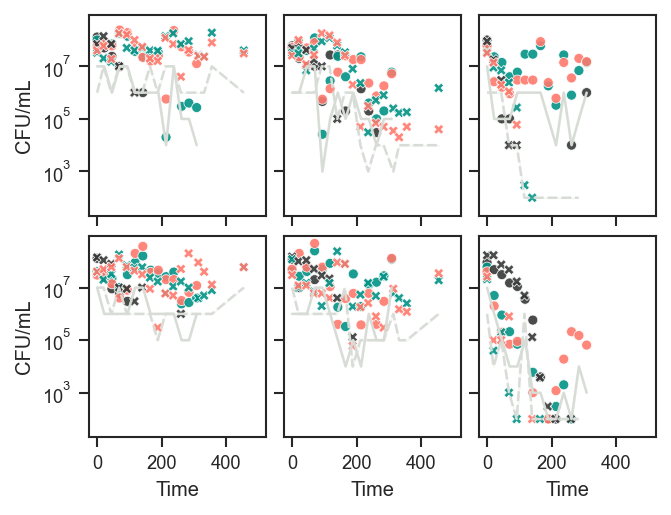

In [41]:
cp = sns.relplot(data=c2[c2['plate'] == 'KAN'],
                 x='time',
                 y='CFU/mL',
                 col='short',
                 col_wrap=3,
                 col_order=['KAN no drug', 'KAN 1xMIC', 'KAN 2xMIC',
                            'PN23 no drug', 'PN23 1xMIC', 'PN23 2xMIC'
                           ],
                 hue='strain',
                 hue_order=['PL', 'PM', 'LM'],
                 palette=['xkcd:teal',
                          'xkcd:salmon',
                          'xkcd:dark grey'],
                 style='replicate',
                 style_order=['1', '2'],
                 # kind='line',
                 height=1.92, aspect=0.77,
                 alpha=0.9,
                 legend=False
                )

cp.map_dataframe(sns.lineplot,
                 x='time',
                 y='detection_limit',
                 style='replicate',
                 style_order=['1', '2'],
                 color='xkcd:light grey'
                )

cp.set(
       yscale='log',
       ylabel='CFU/mL',
       xlabel='Time',
       ylim=(20, 9E8),
       xlim=(-25, 525),
       xticks=[0,
               200,
               400,]
      )

cp.set_titles("")

plt.subplots_adjust(wspace=0.1, hspace=0.1)

sns.despine(right=False, top=False)

plt.savefig('pn_counting.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('pn_counting.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);


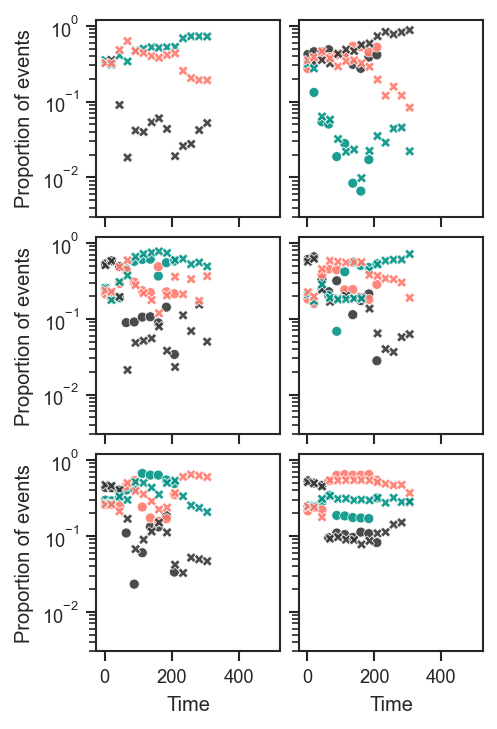

In [33]:
cp = sns.relplot(data=f1,
                 x='time',
                 y='proportion',
                 col='short',
                 col_wrap=2,
                 col_order=['KAN no drug', 'KAN 16x MIC',
                            'PVI no drug', 'PVI 16x MIC',
                            'PVB no drug', 'PVB 16x MIC'
                           ],
                 hue='strain',
                 hue_order=['PL', 'PM', 'LM'],
                 palette=['xkcd:teal',
                          'xkcd:salmon',
                          'xkcd:dark grey'],
                 style='replicate',
                 # kind='line',
                 height=1.7, aspect=1.,
                 alpha=0.9,
                 legend=False
                )

cp.set(
       yscale='log',
       ylabel='Proportion of events',
       xlabel='Time',
       ylim=(0.003, 1.2),
       xlim=(-25, 525),
       xticks=[0,
               200,
               400,]
      )

cp.set_titles("")

plt.subplots_adjust(wspace=0.1, hspace=0.1)

sns.despine(right=False, top=False)

plt.savefig('poxa_flow.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('poxa_flow.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

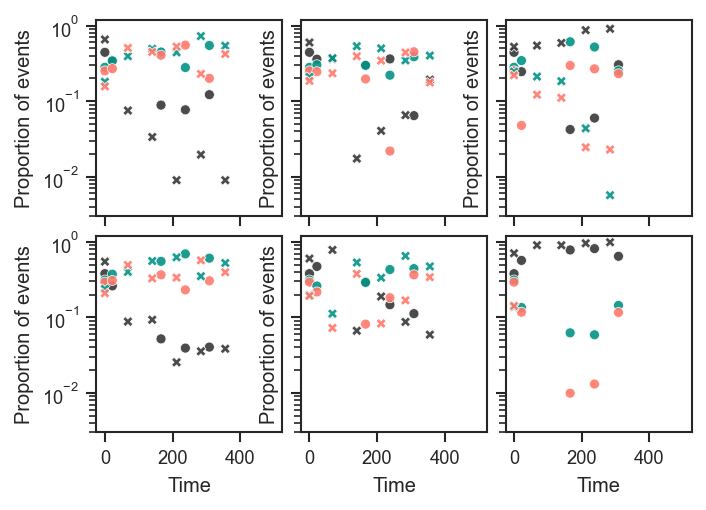

In [34]:
cp = sns.relplot(data=f2,
                 x='time',
                 y='proportion',
                 col='short',
                 col_wrap=3,
                 col_order=['KAN no drug', 'KAN 1xMIC', 'KAN 2xMIC',
                            'PN23 no drug', 'PN23 1xMIC', 'PN23 2xMIC'
                           ],
                 hue='strain',
                 hue_order=['PL', 'PM', 'LM'],
                 palette=['xkcd:teal',
                          'xkcd:salmon',
                          'xkcd:dark grey'],
                 style='replicate',
                 # kind='line',
                 height=1.82, aspect=0.865,
                 alpha=0.9,
                 legend=False
                )

cp.set(
       yscale='log',
       ylabel='Proportion of events',
       xlabel='Time',
       ylim=(0.003, 1.2),
       xlim=(-25, 525),
       xticks=[0,
               200,
               400,]
      )

cp.set_titles("")

plt.subplots_adjust(wspace=0.1, hspace=0.1)

sns.despine(right=False, top=False)

plt.savefig('pn_flow.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('pn_flow.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

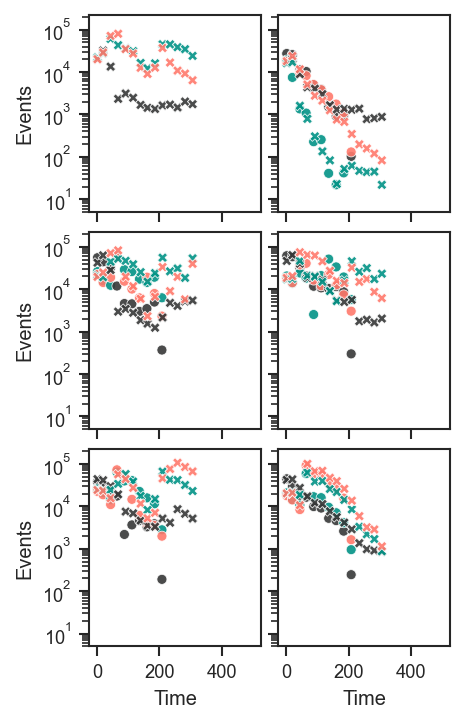

In [35]:
cp = sns.relplot(data=f1,
                 x='time',
                 y='events',
                 col='short',
                 col_wrap=2,
                 col_order=['KAN no drug', 'KAN 16x MIC',
                            'PVI no drug', 'PVI 16x MIC',
                            'PVB no drug', 'PVB 16x MIC'
                           ],
                 hue='strain',
                 hue_order=['PL', 'PM', 'LM'],
                 palette=['xkcd:teal',
                          'xkcd:salmon',
                          'xkcd:dark grey'],
                 style='replicate',
                 # kind='line',
                 height=1.7, aspect=1.,
                 alpha=0.9,
                 legend=False
                )

cp.set(
       yscale='log',
       ylabel='Events',
       xlabel='Time',
       ylim=(5, 225000),
       xlim=(-25, 525),
       xticks=[0,
               200,
               400,]
      )

cp.set_titles("")

plt.subplots_adjust(wspace=0.1, hspace=0.1)

sns.despine(right=False, top=False)

plt.savefig('poxa_flow_events.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('poxa_flow_events.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

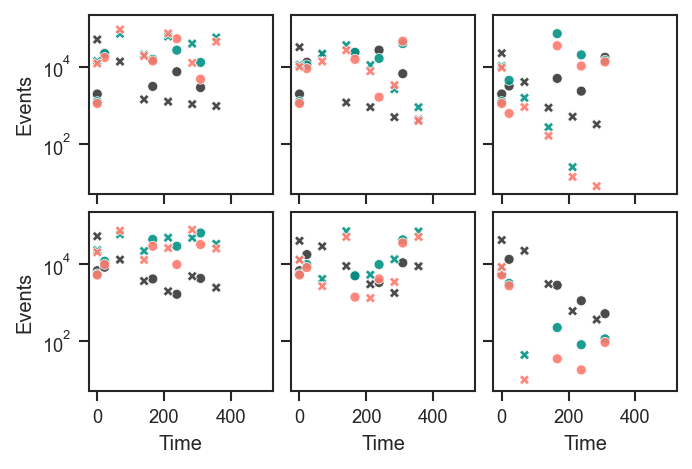

In [36]:
cp = sns.relplot(data=f2,
                 x='time',
                 y='events',
                 col='short',
                 col_wrap=3,
                 col_order=['KAN no drug', 'KAN 1xMIC', 'KAN 2xMIC',
                            'PN23 no drug', 'PN23 1xMIC', 'PN23 2xMIC'
                           ],
                 hue='strain',
                 hue_order=['PL', 'PM', 'LM'],
                 palette=['xkcd:teal',
                          'xkcd:salmon',
                          'xkcd:dark grey'],
                 style='replicate',
                 # kind='line',
                 height=1.7, aspect=0.95,
                 alpha=0.9,
                 legend=False
                )

cp.set(
       yscale='log',
       ylabel='Events',
       xlabel='Time',
       ylim=(5, 225000),
       xlim=(-25, 525),
       xticks=[0,
               200,
               400,]
      )

cp.set_titles("")

plt.subplots_adjust(wspace=0.1, hspace=0.1)

sns.despine(right=False, top=False)

plt.savefig('pn_flow_events.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('pn_flow_events.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);